# 🌸 Classificando Flores Iris com Scikit-Learn

Nesta aula vamos ensinar um computador a **identificar a espécie de uma flor** apenas a partir de 4 medidas (comprimento e largura da pétala e da sépala).

### O que vamos aprender:
1. Como dados "tabulares" (números, não imagens) são representados
2. Como visualizar os dados antes de treinar
3. Como treinar um modelo de classificação
4. Como avaliar se o modelo está bom
5. Como ver, na prática, a lógica de decisão do modelo

💡 **Dica:** rode as células em ordem, de cima para baixo (Shift + Enter).

## 1️⃣ Importando as bibliotecas

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## 2️⃣ Carregando os dados

O dataset Iris tem **150 flores**, divididas em **3 espécies**: *setosa*, *versicolor* e *virginica*.

Para cada flor, temos **4 medidas** (em centímetros):
- comprimento da sépala
- largura da sépala
- comprimento da pétala
- largura da pétala

In [6]:
iris = load_iris()

X = iris.data                    # as 4 medidas de cada flor
y = iris.target                  # a espécie de cada flor (0, 1 ou 2)
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Temos {X.shape[0]} flores.")
print(f"Cada flor tem {X.shape[1]} medidas: {feature_names}")
print(f"As espécies possíveis são: {list(target_names)}")

Temos 150 flores.
Cada flor tem 4 medidas: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
As espécies possíveis são: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


### 👀 Vamos VER os dados em formato de tabela

Antes de treinar qualquer modelo, é fundamental olhar os dados crus.

In [7]:
import pandas as pd

df = pd.DataFrame(X, columns=feature_names)
df['espécie'] = [target_names[i] for i in y]

df.sample(10, random_state=1)  # mostra 10 linhas aleatórias da tabela

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),espécie
14,5.8,4.0,1.2,0.2,setosa
98,5.1,2.5,3.0,1.1,versicolor
75,6.6,3.0,4.4,1.4,versicolor
16,5.4,3.9,1.3,0.4,setosa
131,7.9,3.8,6.4,2.0,virginica
56,6.3,3.3,4.7,1.6,versicolor
141,6.9,3.1,5.1,2.3,virginica
44,5.1,3.8,1.9,0.4,setosa
29,4.7,3.2,1.6,0.2,setosa
120,6.9,3.2,5.7,2.3,virginica


### 📈 Vamos VISUALIZAR as flores em um gráfico

Vamos plotar **comprimento da pétala** vs **largura da pétala**, coloridos por espécie. Isso ajuda a ver se as espécies são fáceis ou difíceis de separar.

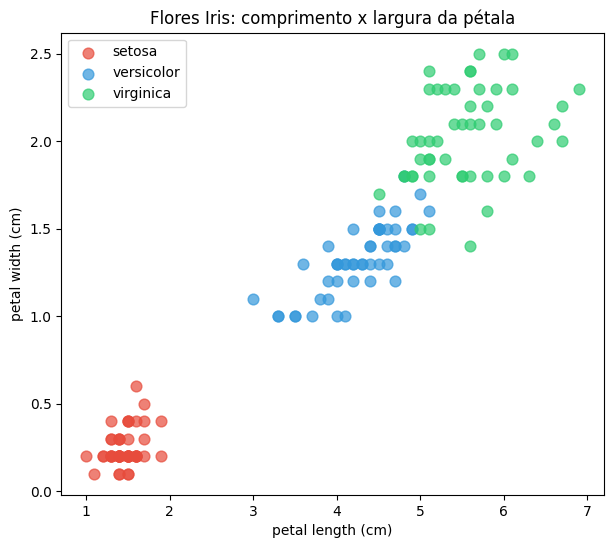

Reparem: a 'setosa' (vermelho) fica bem separada das outras duas.
Já 'versicolor' (azul) e 'virginica' (verde) se misturam um pouco — é aí que o modelo pode errar!


In [8]:
cores = ['#e74c3c', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(7, 6))

for i, nome in enumerate(target_names):
    indices = y == i
    ax.scatter(X[indices, 2], X[indices, 3], label=nome, color=cores[i], alpha=0.7, s=60)

ax.set_xlabel(feature_names[2])
ax.set_ylabel(feature_names[3])
ax.set_title("Flores Iris: comprimento x largura da pétala")
ax.legend()
plt.show()

print("Reparem: a 'setosa' (vermelho) fica bem separada das outras duas.")
print("Já 'versicolor' (azul) e 'virginica' (verde) se misturam um pouco — é aí que o modelo pode errar!")

## 3️⃣ Dividindo em treino e teste

Separamos os dados em duas partes:
- **Treino (80%)**: o modelo aprende com esses exemplos
- **Teste (20%)**: usamos para checar se o modelo aprendeu de verdade, com flores que ele NUNCA viu

⚠️ Nunca avalie um modelo com os mesmos dados que ele usou para aprender!

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% para teste
    random_state=42,       # garante que todos tenham o mesmo resultado
    stratify=y              # mantém a proporção de cada espécie equilibrada
)

print(f"Flores de treino: {len(X_train)}")
print(f"Flores de teste:  {len(X_test)}")

Flores de treino: 120
Flores de teste:  30


## 4️⃣ Treinando o modelo

Vamos usar uma **Árvore de Decisão**: um algoritmo fácil de visualizar, porque ele literalmente toma decisões em formato de "se isso, então aquilo" — parecido com um fluxograma.

Note como o treino é simples: basta chamar `.fit()` passando os dados e as respostas corretas.

In [10]:
modelo = DecisionTreeClassifier(max_depth=3, random_state=42)

modelo.fit(X_train, y_train)

print("Modelo treinado! 🎉")

Modelo treinado! 🎉


### 🌳 Vendo a lógica de decisão do modelo

Esse é o ponto mais legal da árvore de decisão: podemos **literalmente ver como ela pensa**!

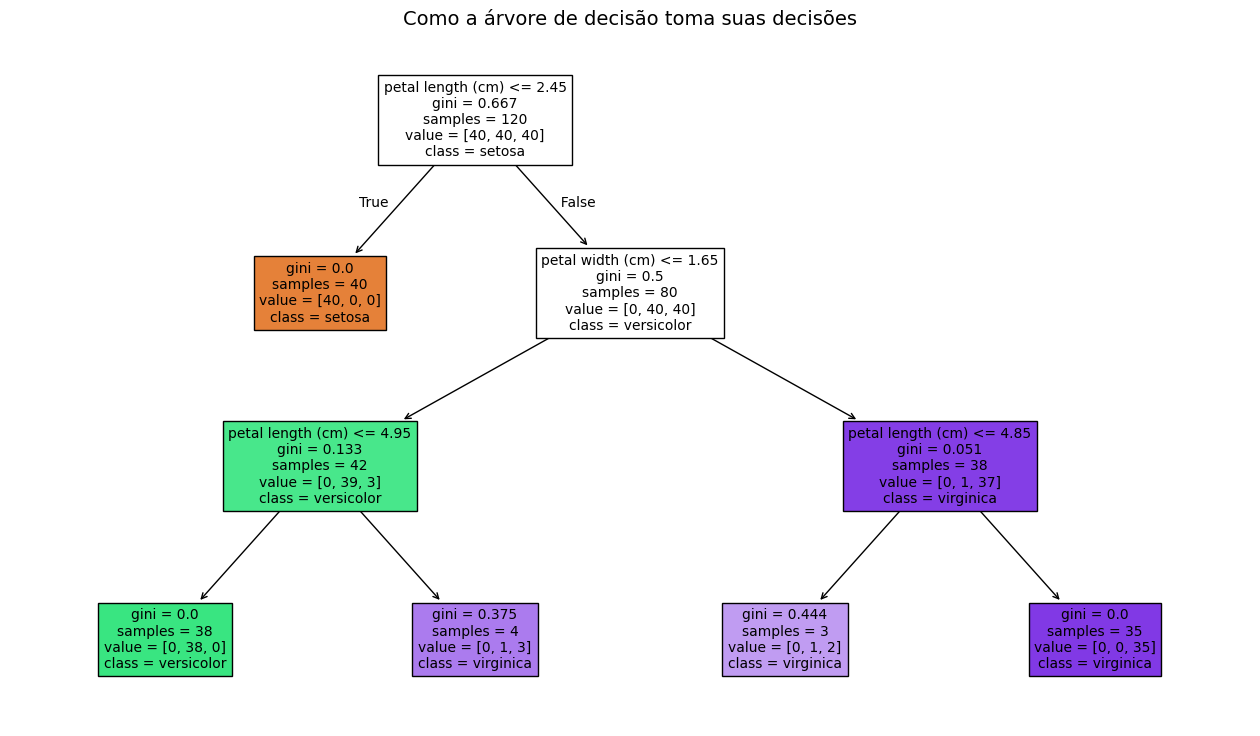

Leia de cima para baixo: cada caixa pergunta algo sobre a flor.
Se a resposta for 'True', vai para a esquerda; se for 'False', vai para a direita.


In [11]:
fig, ax = plt.subplots(figsize=(16, 9))
plot_tree(
    modelo,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    ax=ax,
    fontsize=10
)
plt.title("Como a árvore de decisão toma suas decisões", fontsize=14)
plt.show()

print("Leia de cima para baixo: cada caixa pergunta algo sobre a flor.")
print("Se a resposta for 'True', vai para a esquerda; se for 'False', vai para a direita.")

## 5️⃣ Avaliando o modelo

Agora vamos usar o modelo para prever as espécies do conjunto de **teste** (flores que ele nunca viu) e comparar com a resposta certa.

In [12]:
y_pred = modelo.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {acuracia:.2%}")
print(f"Ou seja: o modelo acertou {int(round(acuracia * len(y_test)))} de {len(y_test)} flores!")

Acurácia do modelo: 96.67%
Ou seja: o modelo acertou 29 de 30 flores!


### 📊 Relatório de classificação

Mostra a precisão para cada espécie separadamente.

In [13]:
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### 🧩 Matriz de confusão

Mostra visualmente quais espécies o modelo confunde entre si. A diagonal principal são os acertos; fora da diagonal são os erros.

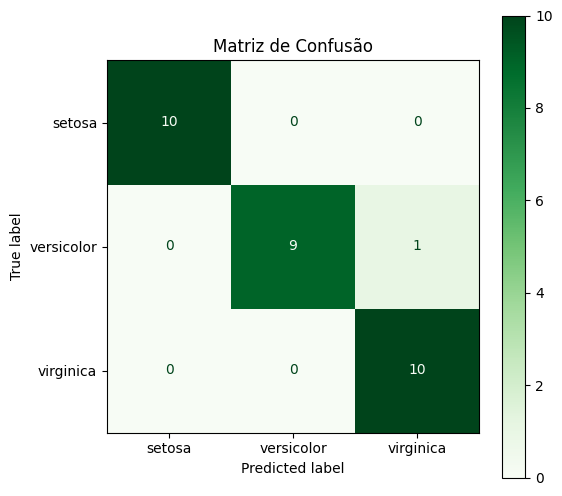

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=target_names,
    ax=ax,
    cmap='Greens'
)
plt.title("Matriz de Confusão")
plt.show()

## 6️⃣ O resultado mais palpável: vendo os erros no gráfico

Vamos voltar ao gráfico de pétalas, mas agora marcando **com um X preto** as flores de teste que o modelo classificou errado.

O modelo errou 1 de 30 flores no conjunto de teste.


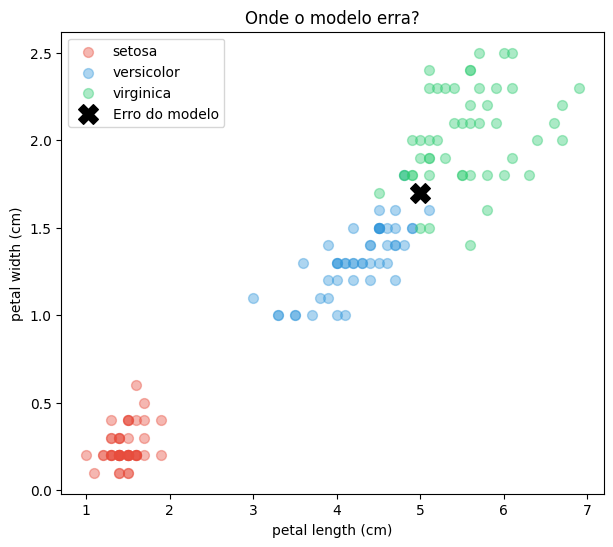

Reparem que os erros (X preto), se houver, tendem a cair bem na fronteira
entre 'versicolor' e 'virginica' — exatamente onde as cores se misturam!


In [15]:
erros = np.where(y_pred != y_test)[0]
print(f"O modelo errou {len(erros)} de {len(y_test)} flores no conjunto de teste.")

fig, ax = plt.subplots(figsize=(7, 6))

# Plotamos todas as flores (treino + teste) coloridas por espécie real
for i, nome in enumerate(target_names):
    indices = y == i
    ax.scatter(X[indices, 2], X[indices, 3], label=nome, color=cores[i], alpha=0.4, s=50)

# Marcamos os erros do teste com um X preto
if len(erros) > 0:
    ax.scatter(
        X_test[erros, 2], X_test[erros, 3],
        marker='X', s=200, color='black', label='Erro do modelo', zorder=5
    )

ax.set_xlabel(feature_names[2])
ax.set_ylabel(feature_names[3])
ax.set_title("Onde o modelo erra?")
ax.legend()
plt.show()

print("Reparem que os erros (X preto), se houver, tendem a cair bem na fronteira")
print("entre 'versicolor' e 'virginica' — exatamente onde as cores se misturam!")

## 7️⃣ Testando com uma flor escolhida por você

Vamos escolher um índice qualquer do conjunto de teste e ver, lado a lado, as medidas da flor e a previsão do modelo.

👉 **Experimente trocar o valor de `indice_escolhido` para outros números (entre 0 e 29) e rode de novo!**

In [16]:
indice_escolhido = 5  # 👈 tente mudar este número

flor_escolhida = X_test[indice_escolhido].reshape(1, -1)  # o modelo espera um "lote" de flores
previsao = modelo.predict(flor_escolhida)[0]
real = y_test[indice_escolhido]

print("Medidas da flor:")
for nome, valor in zip(feature_names, X_test[indice_escolhido]):
    print(f"  {nome}: {valor} cm")

print()
resultado = "✅ ACERTOU" if previsao == real else "❌ ERROU"
print(f"Modelo previu: {target_names[previsao]}")
print(f"Resposta real: {target_names[real]}")
print(f"{resultado}")

Medidas da flor:
  sepal length (cm): 6.3 cm
  sepal width (cm): 3.3 cm
  petal length (cm): 4.7 cm
  petal width (cm): 1.6 cm

Modelo previu: versicolor
Resposta real: versicolor
✅ ACERTOU


### 🌼 Testando com uma flor totalmente inventada

Você também pode inventar as medidas de uma flor que não existe no dataset, e ver o que o modelo prevê!

In [17]:
# 👇 tente mudar essas 4 medidas (em cm) e veja a previsão mudar
sepala_comprimento = 5.0
sepala_largura = 3.0
petala_comprimento = 1.5
petala_largura = 0.3

flor_inventada = [[sepala_comprimento, sepala_largura, petala_comprimento, petala_largura]]
previsao = modelo.predict(flor_inventada)[0]

print(f"O modelo classificou essa flor como: {target_names[previsao]} 🌸")

O modelo classificou essa flor como: setosa 🌸


## 🎓 Resumo da aula

| Etapa | O que fizemos |
|---|---|
| 1. Dados | Carregamos 150 flores com 4 medidas cada |
| 2. Visualização | Vimos a tabela de dados e um gráfico de dispersão |
| 3. Divisão | Separamos 80% para treino e 20% para teste |
| 4. Treino | Usamos `.fit()` para a árvore de decisão aprender |
| 5. Lógica | Visualizamos a árvore e suas perguntas de decisão |
| 6. Avaliação | Medimos acurácia, matriz de confusão e erros reais |

### 🚀 Desafios
1. Troque o modelo `DecisionTreeClassifier` por `KNeighborsClassifier` ou `SVC`. A acurácia muda?
2. Mude `max_depth` da árvore para `1` ou `5`. O que acontece com a árvore desenhada e com a acurácia?
3. No gráfico de pétalas, tente usar `X[:, 0]` e `X[:, 1]` (medidas da sépala) em vez de pétala. As espécies ficam mais ou menos separadas?
4. Invente medidas de flores diferentes na última célula e tente "enganar" o modelo.